## Structured Illumination basics: Measurement Diversity, and the Road to Compressive Imaging

This notebook is different from the previous ones.

For Fourier propagation, holography, ER/HIO, PIE, goal was more towards implementation. Here, the goal is more foundational to understand the basics:

The central idea is:

$$
\textbf{Change the illumination} \quad \Rightarrow \quad \textbf{change the measurement} \quad \Rightarrow \quad \textbf{get more information about the same object.}
$$

Uniform illumination gives one measurement operator.  
Structured illumination gives many measurement operators.

This notebook starts with very simple linear examples, then builds toward Fourier structured illumination and the first intuition behind compressive imaging.

### Big picture: uniform versus structured illumination

Let $O(x,y)$ be an object.

With **uniform illumination**, the illumination pattern is:

$$
S(x,y)=1.
$$

In an incoherent imaging model, the measured image is approximately:

$$
y(x,y)=h(x,y)*O(x,y),
$$

where $h(x,y)$ is the point spread function.

With **structured illumination**, we illuminate with a pattern:

$$
S_m(x,y),
$$

and the measurement becomes:

$$
y_m(x,y)=h(x,y)*[S_m(x,y)O(x,y)].
$$

The object is the same, but every pattern $S_m$ creates a different measurement.

That is the whole point:

$$
S_1O,\quad S_2O,\quad S_3O,\quad \ldots
$$

Each pattern asks the object a different question.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(9)

### Part 1 — The absolute simplest example: two unknown pixels

Suppose the object has two unknown pixel values:

$$
\mathbf{x}=
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix}.
$$

A uniform bucket measurement gives:

$$
y=x_1+x_2.
$$

This is one equation with two unknowns. It is not enough.

But if we use two illumination patterns:

$$
s_1=[1,1],
\qquad
s_2=[1,-1],
$$

then we measure:

$$
y_1=x_1+x_2,
$$

$$
y_2=x_1-x_2.
$$

Now we have two independent equations for two unknowns.

This is structured illumination in its simplest possible form.

In [3]:

# True two-pixel object.
x_true = np.array([7.0, 3.0])

# Two illumination patterns.
s1 = np.array([1.0, 1.0])    # uniform pattern
s2 = np.array([1.0, -1.0])   # contrast pattern

# Stack patterns into a measurement matrix.
A = np.vstack([s1, s2])

# Measurements.
y = A @ x_true

# Reconstruct by solving A x = y.
x_recon = np.linalg.solve(A, y)

print("True object x:        ", x_true)
print("Measurements y:       ", y)
print("Measurement matrix A:\n", A)
print("Reconstructed object: ", x_recon)


True object x:         [7. 3.]
Measurements y:        [10.  4.]
Measurement matrix A:
 [[ 1.  1.]
 [ 1. -1.]]
Reconstructed object:  [7. 3.]


The important lesson is not the specific numbers. The lesson is:

> A pattern is a weighted question about the object.

Mathematically:

$$
y_m=s_m^T x.
$$

Multiple patterns give multiple rows of a measurement matrix:

$$
\mathbf{y}=A\mathbf{x}.
$$


### Part 2 — From two pixels to many pixels

Now suppose the object has $N$ pixels:

$$
\mathbf{x}=[x_1,x_2,\ldots,x_N]^T.
$$

A pattern is also a vector:

$$
\mathbf{s}_m=[s_{m1},s_{m2},\ldots,s_{mN}]^T.
$$

A bucket detector measures the overlap between the pattern and object:

$$
y_m=\mathbf{s}_m^T\mathbf{x}.
$$

Stacking $M$ measurements gives:

$$
\mathbf{y}=A\mathbf{x},
$$

where each row of $A$ is one illumination pattern.

If $A$ has enough independent rows, we can reconstruct $\mathbf{x}$.  
If the rows are redundant or too few, reconstruction fails or becomes ambiguous.


In [4]:

# Create a simple 1D object.
N = 64
x_axis = np.linspace(0, 1, N)

x_true = (
    1.2 * np.exp(-((x_axis - 0.25) / 0.05)**2)
    + 0.8 * np.exp(-((x_axis - 0.62) / 0.08)**2)
    + 0.25 * ((x_axis > 0.75) & (x_axis < 0.9))
)

# Case 1: only one uniform measurement.
A_uniform = np.ones((1, N))
y_uniform = A_uniform @ x_true

# Case 2: N independent random +/-1 patterns.
A_random = rng.choice([-1.0, 1.0], size=(N, N))
y_random = A_random @ x_true

# Reconstruct from random patterns by least squares.
x_recon_random, *_ = np.linalg.lstsq(A_random, y_random, rcond=None)

print("Uniform measurement gives only one number:", y_uniform[0])
print("Random measurement matrix rank:", np.linalg.matrix_rank(A_random), "out of", N)
print("Random measurement matrix condition number:", np.linalg.cond(A_random))


Uniform measurement gives only one number: 16.096409483251822
Random measurement matrix rank: 64 out of 64
Random measurement matrix condition number: 346.852401387579


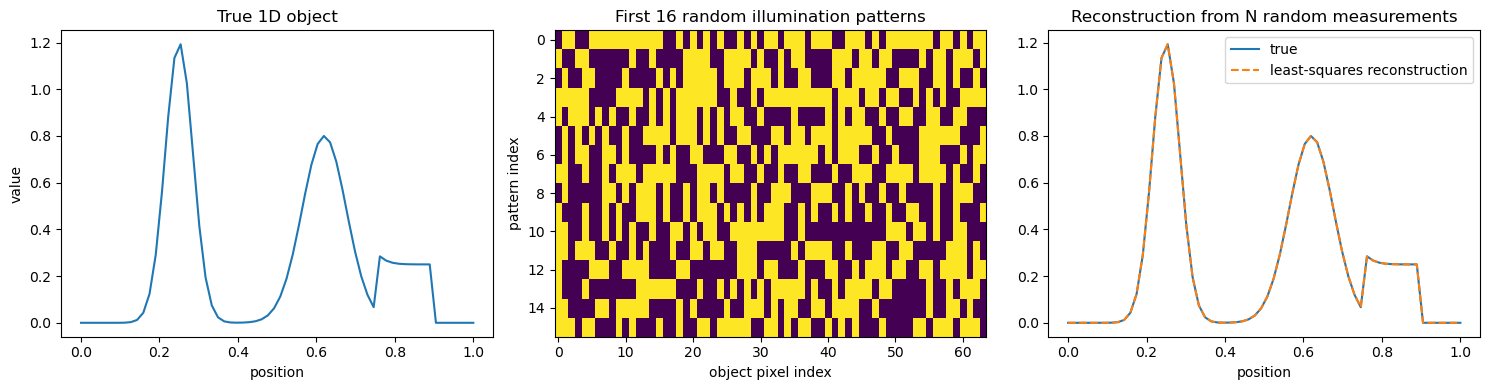

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x_axis, x_true)
axes[0].set_title("True 1D object")
axes[0].set_xlabel("position")
axes[0].set_ylabel("value")

axes[1].imshow(A_random[:16], aspect="auto")
axes[1].set_title("First 16 random illumination patterns")
axes[1].set_xlabel("object pixel index")
axes[1].set_ylabel("pattern index")

axes[2].plot(x_axis, x_true, label="true")
axes[2].plot(x_axis, x_recon_random, "--", label="least-squares reconstruction")
axes[2].set_title("Reconstruction from N random measurements")
axes[2].set_xlabel("position")
axes[2].legend()

plt.tight_layout()
plt.show()


The uniform pattern gives only one number:

$$
y=\sum_n x_n.
$$

This cannot reconstruct the object.

The random patterns give $N$ different equations for $N$ unknown pixels. If the measurement matrix is full rank and reasonably conditioned, least squares can recover the object.

The matrix $A$ is determined by illumination.

### Part 3 — 2D object with bucket measurements

Now we move from a 1D vector to a 2D image.

A 2D object $O(x,y)$ can be flattened into a vector $\mathbf{x}$.  
A 2D illumination pattern $S_m(x,y)$ can also be flattened into a row of $A$.

A bucket detector measurement is:

$$
y_m=\sum_{x,y}S_m(x,y)O(x,y).
$$

This is still:

$$
\mathbf{y}=A\mathbf{x}.
$$


In [6]:

def make_2d_object(n):
    """Create a simple synthetic 2D object with blobs and edges."""
    yy, xx = np.meshgrid(np.linspace(-1, 1, n), np.linspace(-1, 1, n), indexing="ij")
    obj = (
        1.0 * np.exp(-((xx + 0.35)**2 + (yy + 0.2)**2) / 0.03)
        + 0.8 * np.exp(-((xx - 0.25)**2 + (yy - 0.25)**2) / 0.05)
        + 0.5 * ((np.abs(xx) < 0.15) & (yy > 0.25) & (yy < 0.55))
        + 0.4 * ((xx + yy > 0.65) & (xx < 0.75) & (yy < 0.75))
    )
    return obj

n_img = 72
obj2d = make_2d_object(n_img)
x2d = obj2d.ravel()
num_pixels = x2d.size

# Use as many random patterns as pixels for exact-ish least-squares reconstruction.
M = num_pixels
patterns = rng.choice([-1.0, 1.0], size=(M, num_pixels))
measurements = patterns @ x2d

x2d_recon, *_ = np.linalg.lstsq(patterns, measurements, rcond=None)
obj2d_recon = x2d_recon.reshape(n_img, n_img)

print("Number of pixels:", num_pixels)
print("Number of measurements:", M)
print("Pattern matrix rank:", np.linalg.matrix_rank(patterns))


Number of pixels: 5184
Number of measurements: 5184
Pattern matrix rank: 5184


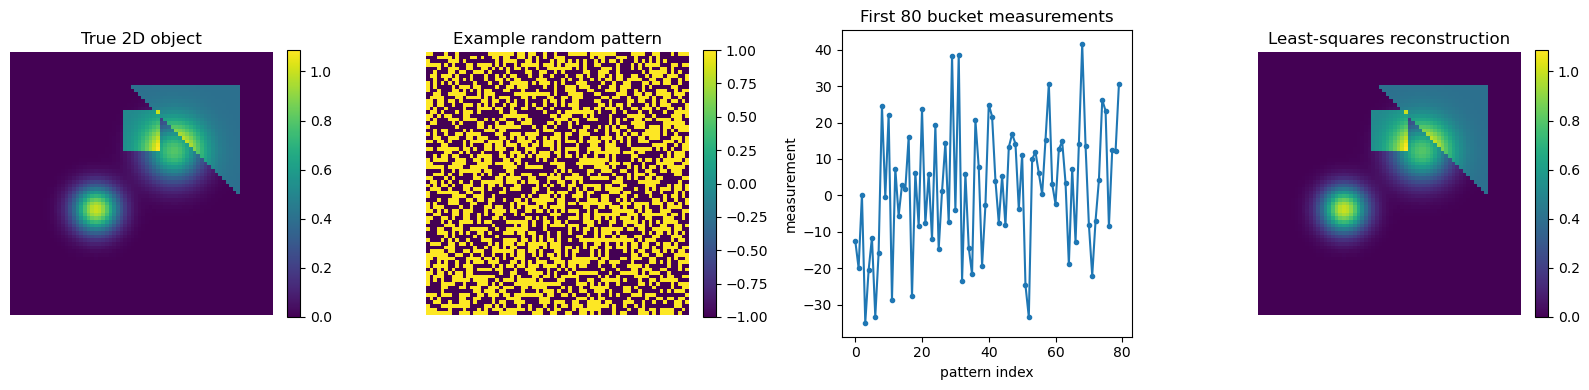

In [7]:

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

im0 = axes[0].imshow(obj2d, origin="lower")
axes[0].set_title("True 2D object")
axes[0].set_axis_off()
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(patterns[0].reshape(n_img, n_img), origin="lower")
axes[1].set_title("Example random pattern")
axes[1].set_axis_off()
plt.colorbar(im1, ax=axes[1], fraction=0.046)

axes[2].plot(measurements[:80], marker="o", markersize=3)
axes[2].set_title("First 80 bucket measurements")
axes[2].set_xlabel("pattern index")
axes[2].set_ylabel("measurement")

im3 = axes[3].imshow(obj2d_recon, origin="lower")
axes[3].set_title("Least-squares reconstruction")
axes[3].set_axis_off()
plt.colorbar(im3, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.show()


### Part 4 — First bridge to compressive imaging

Suppose we have a system where:
$$M < N$$

* **The Problem:** There are fewer measurements ($M$) than pixels ($N$). 
* **The Naive View:** Reconstruction is mathematically impossible because the system is underdetermined.

#### The Power of Sparsity

But suppose the object is **sparse**. 

* **Example:** An image has $10,000$ pixels, but contains only $20$ nonzero bright particles.
* **The Reality:** Even though the vector $x$ has $10,000$ entries, its true information content is much smaller.

> **Compressive Sensing Principle:** If $x$ is sparse and $A$ is a good measurement matrix, then $x$ can sometimes be recovered from far fewer than $N$ measurements.


#### Mathematical Formulation

A common optimization problem used for reconstruction is:

$$\hat{x} = \arg\min_{x} \frac{1}{2} \|Ax - y\|_2^2 + \lambda \|x\|_1$$

##### Breakdown of the Objective Function:
1. **Data Fidelity Term ($\frac{1}{2} \|Ax - y\|_2^2$):** Ensures consistency with measurements ($Ax \approx y$).
2. **Regularization Term ($\lambda \|x\|_1$):** Forces the solution $x$ to be sparse.

The $\ell_1$ norm is defined as:
$$\|x\|_1 = \sum_{n} |x_n|$$

*It acts as a sparsity-promoting penalty, encouraging many entries in $x$ to become exactly zero.*


#### Alternative Sparsity Domains

If the object is not sparse in the pixel domain, it may be sparse in a transform domain:

* **Gradients (Edges):** $\nabla x$
* **Wavelet Basis:** $W x$

That is what **"sparsity priors"** means. It is not magic. It simply means:

> **Core Logic:** Among all possible objects that perfectly explain the measurements, choose the one that is the sparsest or simplest according to a predefined rule.


In [8]:

# Sparse 1D object.
N_sparse = 128
M_sparse = 40  # fewer measurements than unknowns

x_sparse_true = np.zeros(N_sparse)
nonzero_indices = rng.choice(N_sparse, size=8, replace=False)
x_sparse_true[nonzero_indices] = rng.uniform(0.5, 1.5, size=len(nonzero_indices))

# Random measurement matrix with normalized columns.
A_cs = rng.normal(size=(M_sparse, N_sparse)) / np.sqrt(M_sparse)
y_cs = A_cs @ x_sparse_true

# Minimum-norm least-squares solution for underdetermined system.
x_min_norm = np.linalg.pinv(A_cs) @ y_cs

def soft_threshold(z, threshold):
    """Soft-thresholding operator for L1 regularization."""
    return np.sign(z) * np.maximum(np.abs(z) - threshold, 0.0)

def ista_lasso(A, y, lam=0.04, num_iter=500):
    """
    Basic ISTA solver for:
        0.5 ||A x - y||_2^2 + lam ||x||_1

    This is intentionally simple and educational, not optimized.
    """
    L = np.linalg.norm(A, ord=2)**2
    step = 1.0 / L
    x = np.zeros(A.shape[1])
    objective = []
    for _ in range(num_iter):
        grad = A.T @ (A @ x - y)
        x = soft_threshold(x - step * grad, lam * step)
        obj = 0.5 * np.linalg.norm(A @ x - y)**2 + lam * np.sum(np.abs(x))
        objective.append(obj)
    return x, np.array(objective)

x_l1, obj_history = ista_lasso(A_cs, y_cs, lam=0.04, num_iter=500)

print("Unknowns N:", N_sparse)
print("Measurements M:", M_sparse)
print("True number of nonzero entries:", np.sum(np.abs(x_sparse_true) > 1e-12))
print("Nonzeros in min-norm solution above 1e-3:", np.sum(np.abs(x_min_norm) > 1e-3))
print("Nonzeros in L1 solution above 1e-3:", np.sum(np.abs(x_l1) > 1e-3))


Unknowns N: 128
Measurements M: 40
True number of nonzero entries: 8
Nonzeros in min-norm solution above 1e-3: 127
Nonzeros in L1 solution above 1e-3: 24


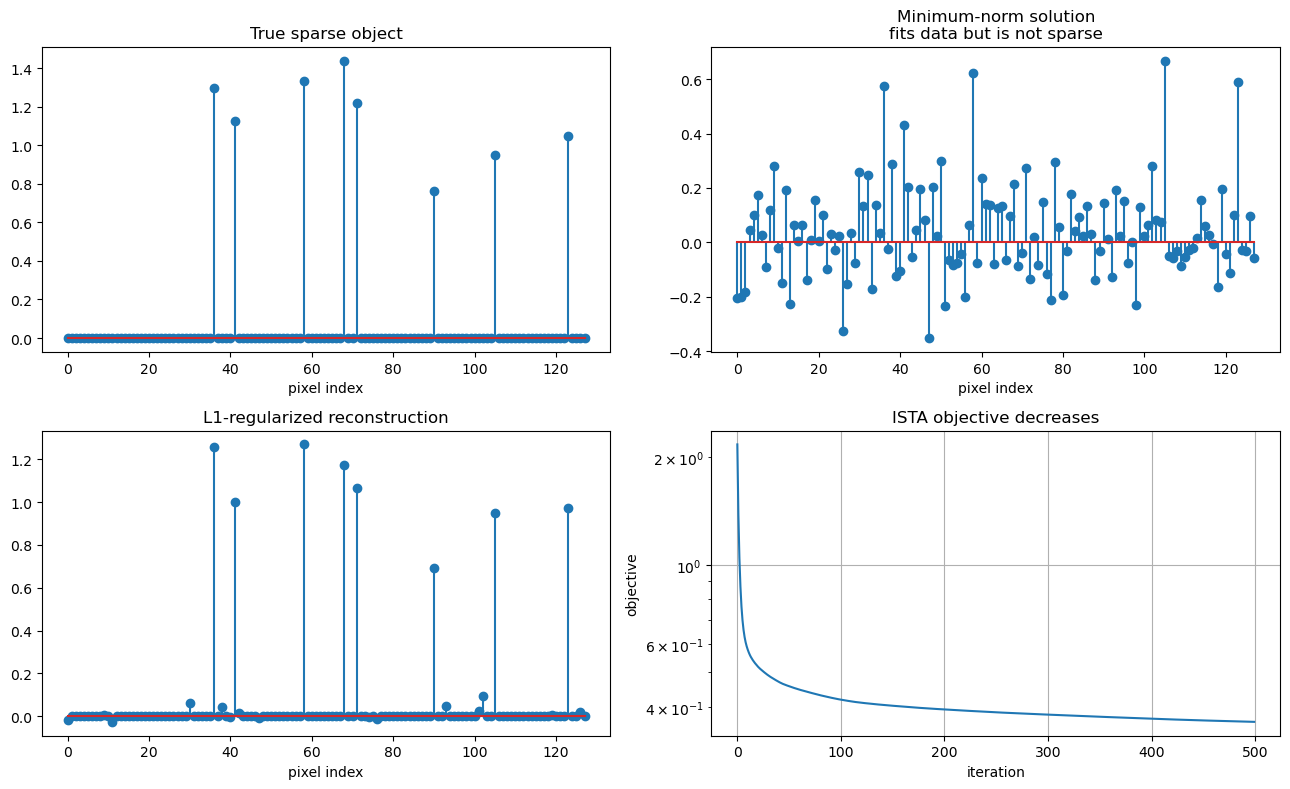

In [9]:

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].stem(x_sparse_true)
axes[0, 0].set_title("True sparse object")
axes[0, 0].set_xlabel("pixel index")

axes[0, 1].stem(x_min_norm)
axes[0, 1].set_title("Minimum-norm solution\nfits data but is not sparse")
axes[0, 1].set_xlabel("pixel index")

axes[1, 0].stem(x_l1)
axes[1, 0].set_title("L1-regularized reconstruction")
axes[1, 0].set_xlabel("pixel index")

axes[1, 1].semilogy(obj_history)
axes[1, 1].set_title("ISTA objective decreases")
axes[1, 1].set_xlabel("iteration")
axes[1, 1].set_ylabel("objective")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


Both the minimum-norm solution and the L1 solution can match the measurements reasonably well.

But the underdetermined system has infinitely many solutions.

The minimum-norm solution spreads energy over many pixels.

The L1 solution prefers sparse solutions, so it can recover the sparse object much better.

This is what a prior does:

> Among all measurement-consistent objects, choose the one that satisfies the expected structure.
